# SAFFRON tutorial: Novae embeddings on the colorectal tumor-stroma boundary

1. Train a Matryoshka SAE on SFM embeddings `Z` to learn sparse, interpretable features `H`.
2. Evaluate `H` against a known measure of spatial variation `τ`: correlate every feature with `τ`, then use orthogonal matching pursuit (OMP) to find a minimal reconstructing subset.

SAFFRON expects an `AnnData` with:
- `adata.obsm[embedding_key]` — the embedding `Z` (any SFM, single-cell FM, or raw gene expression)
- `adata.obs[tau_key]` — the known spatial-variation measure `τ`

`data/colorectal_novae_train.h5ad` also bundles `adata.obsm["sae_features"]`, the actual SAE features reported in the paper for this dataset — `.fit(..., features_key="sae_features")` loads these instead of retraining, so the feature numbers below match the paper. `adata.X` holds the top 3000 highly-variable genes (log-normalized), used later to check the SAE features against raw gene expression.

In [1]:
import numpy as np
import anndata

from saffron import (
    SAFFRON, select_domains, top_features, to_dense, gene_row,
    plot_spatial_grid, plot_gene_tracks, plot_omp_curve,
)
from saffron.omp import omp_reconstruct

In [2]:
adata = anndata.read_h5ad("data/colorectal_novae_train.h5ad")
adata

AnnData object with n_obs × n_vars = 3900 × 3000
    obs: 'isodepth', 'domain'
    uns: 'tumor_domain'
    obsm: 'X_embedding', 'sae_features', 'spatial'

## Fit the SAE, then evaluate against τ on the tumor-stroma boundary region

The SAE trains on the full tissue so its features generalize beyond any one region; we then evaluate it restricted to the tumor domain plus its adjacent stroma domain (`adata.uns["tumor_domain"]`).

In [3]:
model = SAFFRON(latent_dim=256, k=16, matryoshka_dims=[64, 128, 256], epochs=100)
model.fit(adata, features_key="sae_features")

region = select_domains(adata, [adata.uns["tumor_domain"], adata.uns["tumor_domain"] - 1])
result = model.evaluate(region, tau_key="isodepth", features_key="sae_features")

corr = result.correlation
print(f"Best feature: #{corr.best_feature}   rho = {corr.best_rho:+.3f}   "
      f"(support: {corr.support_size[corr.best_feature]} spots)")

Best feature: #132   rho = -0.927   (support: 10 spots)


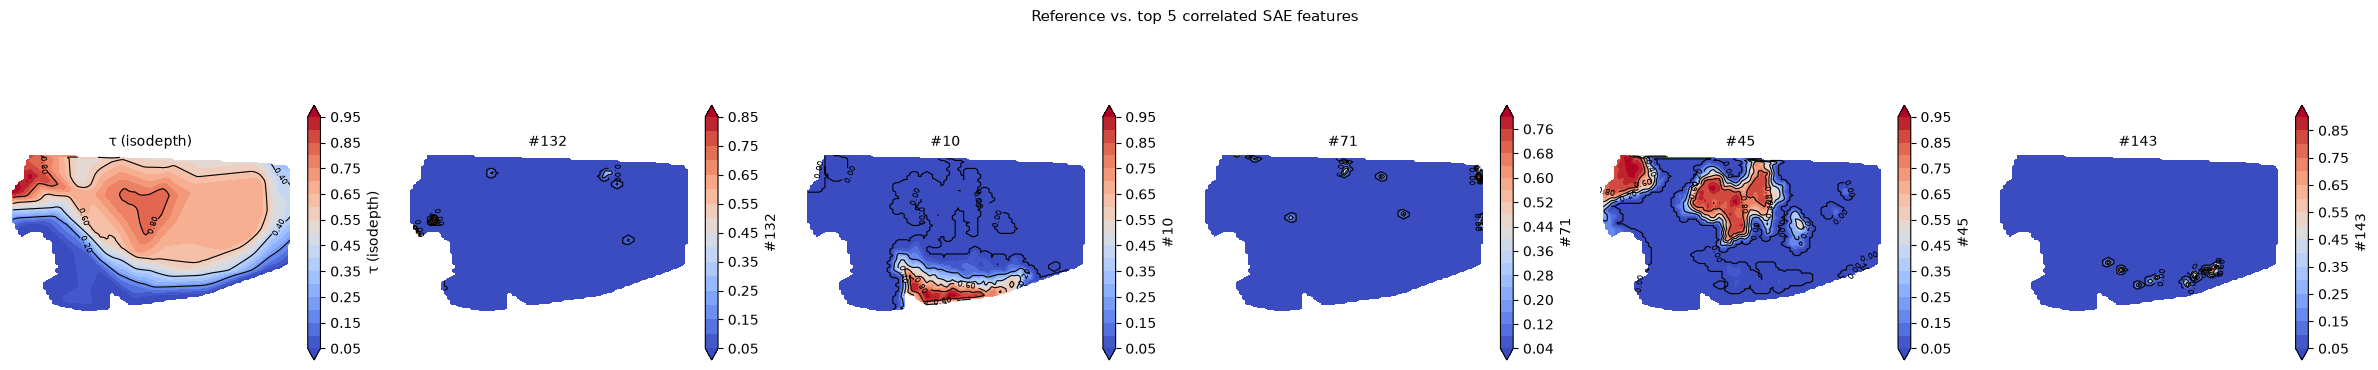

In [4]:
top5 = top_features(corr)
plot_spatial_grid(region, {
    "τ (isodepth)": region.obs["isodepth"].values,
    **{f"#{i}": region.obsm["sae_features"][:, i] for i in top5},
}, suptitle="Reference vs. top 5 correlated SAE features");

## Minimal reconstructing feature set (OMP)

Cross-validated R² as a function of the number of features shows how quickly reconstruction quality saturates, alongside a dense RidgeCV-on-all-features reference.

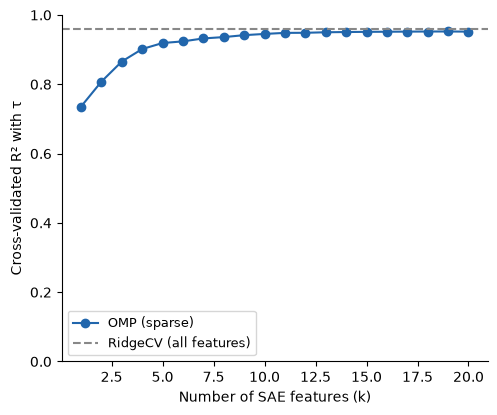

In [5]:
plot_omp_curve(result.omp_curve);

Reconstructed τ from features [np.int64(45), np.int64(210)]   R2 = 0.808


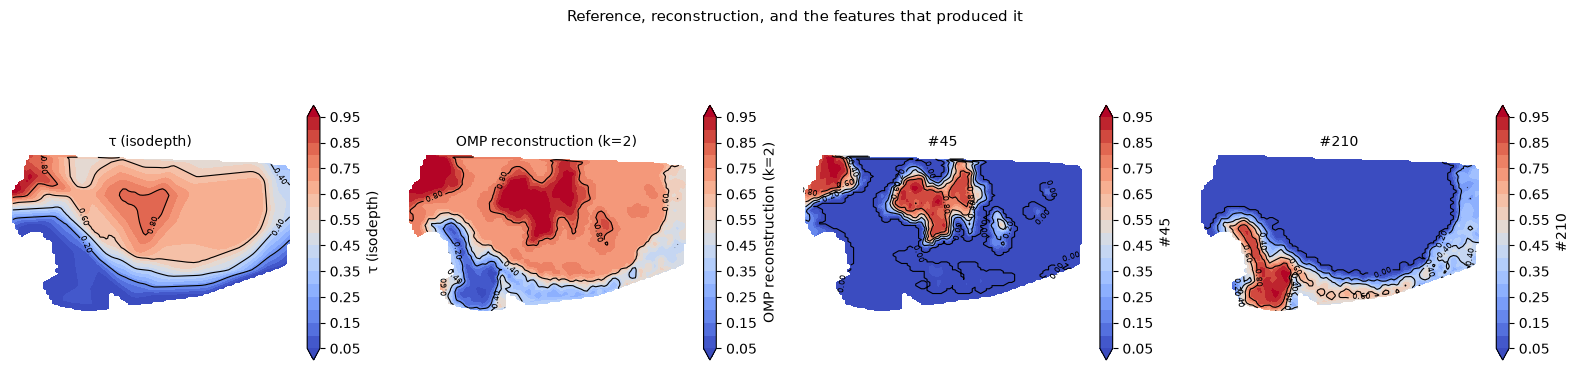

In [6]:
recon = omp_reconstruct(region.obsm["sae_features"], region.obs["isodepth"].values, k=2)
print(f"Reconstructed τ from features {recon.selected_features}   R2 = {recon.r2:.3f}")

plot_spatial_grid(region, {
    "τ (isodepth)": region.obs["isodepth"].values,
    "OMP reconstruction (k=2)": recon.reconstructed,
    **{f"#{f}": region.obsm["sae_features"][:, f] for f in recon.selected_features},
}, suptitle="Reference, reconstruction, and the features that produced it");

## Checking SAE features against raw gene expression

`SAFFRON.evaluate` takes any `(N, M)` feature matrix `H` — it doesn't have to come from
`sae_features`. Passing `adata.X` (raw gene expression) instead finds the individual genes that
track τ most strongly, independent of the SAE.

We do this over two regions already used above: tumor-only spots, and the tumor-stroma boundary.
The cell below prints the top 20 genes by |ρ| in each.

In [7]:
tumor_only = select_domains(adata, [adata.uns["tumor_domain"]])

tumor_result = SAFFRON().evaluate(tumor_only, H=to_dense(tumor_only.X), tau_key="isodepth",
                                   restrict_support=False, run_omp=False)
boundary_result = SAFFRON().evaluate(region, H=to_dense(region.X), tau_key="isodepth",
                                      restrict_support=False, run_omp=False)

print("Top 20 genes, tumor-only spots:")
for i in top_features(tumor_result.correlation, n=20):
    print(f"  {tumor_only.var_names[i]:10s} rho = {tumor_result.correlation.rho[i]:+.3f}")

print("\nTop 20 genes, tumor-stroma boundary:")
for i in top_features(boundary_result.correlation, n=20):
    print(f"  {region.var_names[i]:10s} rho = {boundary_result.correlation.rho[i]:+.3f}")

Top 20 genes, tumor-only spots:
  S100A6     rho = +0.588
  ID1        rho = +0.462
  SCD        rho = +0.451
  CSTB       rho = +0.446
  PTPRO      rho = -0.443
  CCDC88B    rho = -0.440
  PROM1      rho = -0.438
  TNFRSF6B   rho = -0.408
  LCN2       rho = -0.408
  MUC12      rho = -0.378
  EPHB3      rho = -0.378
  LFNG       rho = -0.352
  IGHA1      rho = -0.349
  LGR5       rho = -0.342
  CEACAM5    rho = +0.329
  LRP4       rho = -0.325
  FABP5      rho = +0.325
  HSPE1      rho = +0.323
  RPL34      rho = +0.319
  INSIG1     rho = +0.308

Top 20 genes, tumor-stroma boundary:
  S100A6     rho = +0.802
  IGHA1      rho = -0.774
  FCGBP      rho = -0.767
  RPL34      rho = +0.725
  JCHAIN     rho = -0.722
  RPL4       rho = +0.719
  RPL17      rho = +0.700
  HLA-B      rho = -0.662
  MT-ND1     rho = -0.638
  CLCA1      rho = -0.636
  MUC2       rho = -0.621
  IGHG4      rho = -0.617
  B3GNT7     rho = -0.615
  ST6GALNAC6 rho = -0.607
  ZG16       rho = -0.596
  MUC12      rho = -

S100A6 and PTPRO top the tumor-only ranking (increasing and decreasing respectively); FCGBP is
near the top of the boundary ranking, and SCD is within its top 20. We plot these four genes —
pulled directly from the tables above, by name — against τ and the reconstructed axis.

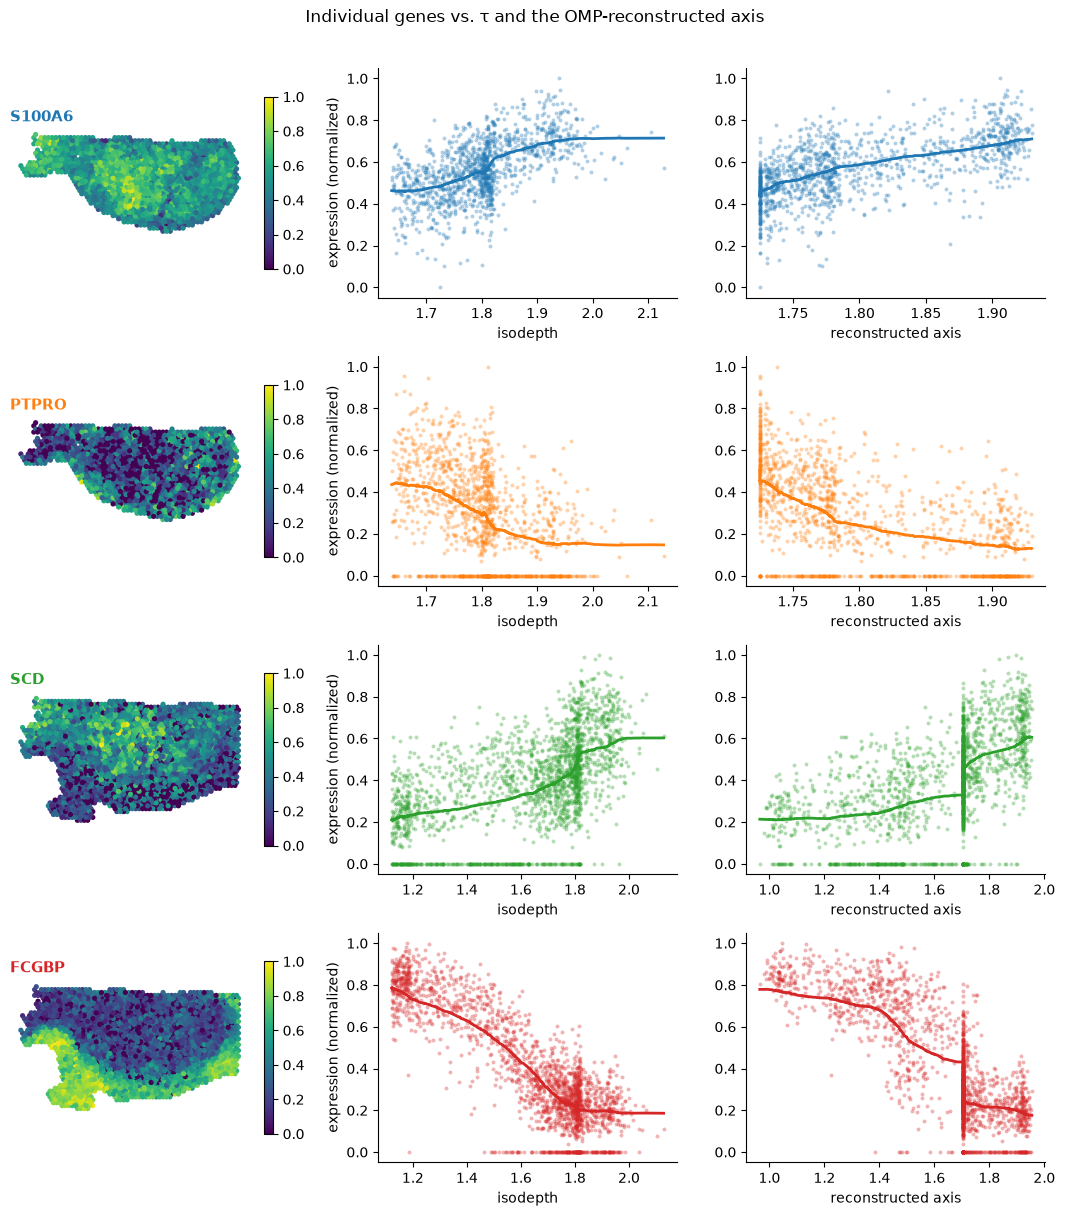

In [8]:
recon_tumor = omp_reconstruct(tumor_only.obsm["sae_features"], tumor_only.obs["isodepth"].values, k=2)

rows = [
    gene_row(tumor_only, "S100A6", reconstructed=recon_tumor.reconstructed),
    gene_row(tumor_only, "PTPRO", reconstructed=recon_tumor.reconstructed),
    gene_row(region, "SCD", reconstructed=recon.reconstructed),
    gene_row(region, "FCGBP", reconstructed=recon.reconstructed),
]
plot_gene_tracks(rows, suptitle="Individual genes vs. τ and the OMP-reconstructed axis");

## Using this on your own data

Any `AnnData` with an embedding in `.obsm` and a spatial-variation measure in `.obs` works — swap `embedding_key`/`tau_key`/`features_key` and `select_domains`'s domain list for your own. SAFFRON does not generate embeddings or spatial-variation measures itself.